# Lab 05 — Introduction to Deep Neural Networks

**Task:** build and analyze a two-layer fully connected MNIST classifier with
Keras. The architecture is:

`INPUT -> LINEAR -> RELU -> LINEAR -> SOFTMAX`

We use a hidden layer with 512 units, stochastic gradient descent, categorical
cross-entropy, mini-batches of 128, and ten training epochs. The test set is
kept separate; 10% of the training data is used for validation.

Keras references: [Sequential](https://keras.io/api/models/sequential/),
[optimizers](https://keras.io/api/optimizers/), and
[Keras getting started](https://keras.io/getting_started/).


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

from pathlib import Path

import keras
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
NUM_CLASSES = 10
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "keras" and (PROJECT_DIR / "keras").is_dir():
    PROJECT_DIR = PROJECT_DIR / "keras"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
keras.utils.set_random_seed(RANDOM_STATE)
print(f"Keras {keras.__version__}; backend: {keras.config.backend()}")


Keras 3.15.1; backend: tensorflow


## 1. Learn about the data

Inspect shape, type, range, class distribution, and representative images
before modeling.


In [2]:
(train_images_raw, train_labels), (test_images_raw, test_labels) = keras.datasets.mnist.load_data()
assert train_images_raw.shape == (60000, 28, 28)
assert test_images_raw.shape == (10000, 28, 28)
assert train_labels.shape == (60000,)
assert test_labels.shape == (10000,)
assert train_images_raw.dtype == np.uint8
assert np.isfinite(train_images_raw).all()
assert set(np.unique(train_labels)) == set(range(NUM_CLASSES))

print(f"Feature type: {type(train_images_raw).__name__}")
print(f"Label type: {type(train_labels).__name__}")
print(f"Feature dtype: {train_images_raw.dtype}")
print(f"Label dtype: {train_labels.dtype}")
print(f"Train features: {train_images_raw.shape}; train labels: {train_labels.shape}")
print(f"Test features: {test_images_raw.shape}; test labels: {test_labels.shape}")
print(f"Pixel range: {train_images_raw.min()} to {train_images_raw.max()}")


Feature type: ndarray
Label type: ndarray
Feature dtype: uint8
Label dtype: uint8
Train features: (60000, 28, 28); train labels: (60000,)
Test features: (10000, 28, 28); test labels: (10000,)
Pixel range: 0 to 255


,count
digit,
0,5923
1,6742
2,5958
3,6131
4,5842
5,5421
6,5918
7,6265
8,5851


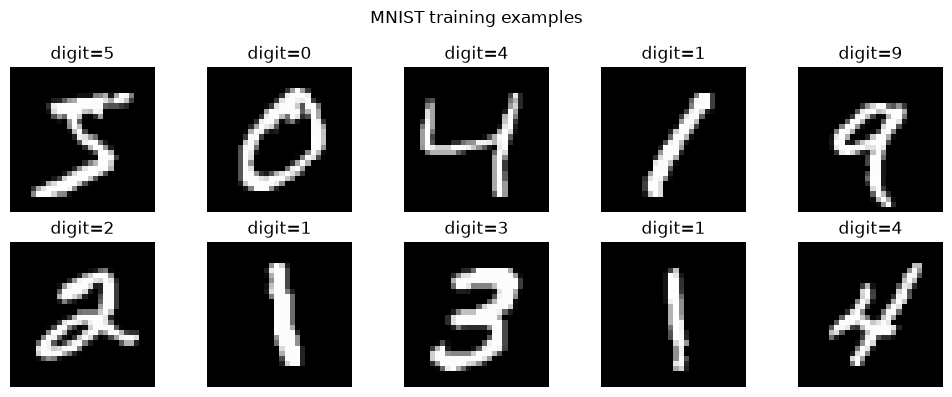

In [3]:
class_counts = (
    pd.Series(train_labels)
    .value_counts()
    .sort_index()
    .rename_axis("digit")
    .to_frame("count")
)
display(class_counts)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.flat, train_images_raw[:10], train_labels[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(f"digit={label}")
    axis.axis("off")
fig.suptitle("MNIST training examples")
fig.tight_layout()
display(fig)
plt.close(fig)


## 2. Build the neural network model

The output has ten softmax probabilities, one for each digit. The hidden layer
has 512 ReLU units as required by the lab.


In [4]:
def build_model(optimizer):
    model = keras.Sequential(
        [
            keras.Input(shape=(28 * 28,), name="pixels"),
            keras.layers.Dense(512, activation="relu"),
            keras.layers.Dense(NUM_CLASSES, activation="softmax"),
        ],
        name="mnist_dnn",
    )
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

baseline = build_model(keras.optimizers.SGD(learning_rate=0.01))
baseline.summary()


Model: "mnist_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Preprocess the data

Flatten each image to 784 features, normalize pixels to `[0, 1]`, and one-hot
encode the labels.


In [5]:
train_images = train_images_raw.reshape((len(train_images_raw), -1)).astype("float32") / 255.0
test_images = test_images_raw.reshape((len(test_images_raw), -1)).astype("float32") / 255.0
train_targets = keras.utils.to_categorical(train_labels, NUM_CLASSES)
test_targets = keras.utils.to_categorical(test_labels, NUM_CLASSES)

assert train_images.shape == (60000, 784)
assert test_images.shape == (10000, 784)
assert train_targets.shape == (60000, NUM_CLASSES)
assert np.isclose(train_images.min(), 0.0)
assert train_images.max() <= 1.0


## 4. Model training

Train for ten epochs with batch size 128. `validation_split=0.1` reserves 10%
of the current training array for validation and returns a history object.


In [6]:
keras.utils.set_random_seed(RANDOM_STATE)
history = baseline.fit(
    train_images,
    train_targets,
    epochs=10,
    batch_size=128,
    validation_split=0.10,
    verbose=0,
)
history_frame = pd.DataFrame(history.history)
display(history_frame)


,accuracy,loss,val_accuracy,val_loss
0,0.735889,1.169662,0.879333,0.598512
1,0.865593,0.557100,0.902667,0.408168
2,0.885704,0.443257,0.911833,0.343002
3,0.894907,0.391868,0.917500,0.308811
4,0.901981,0.360546,0.923000,0.286855
5,0.907167,0.338426,0.926833,0.270949
6,0.911759,0.321346,0.929333,0.258456
7,0.915315,0.307403,0.932833,0.248163
8,0.918481,0.295572,0.935500,0.239343
9,0.921148,0.285262,0.936333,0.231590


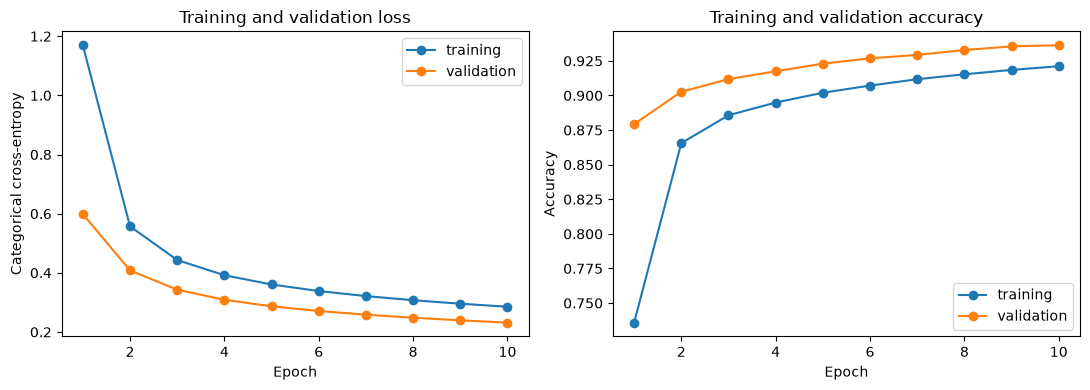

Lowest validation loss: epoch 10
Highest validation accuracy: epoch 10
Final validation-minus-training loss gap: -0.0537
Interpretation: no loss-based overfitting is visible by the final epoch.


In [7]:
epochs = np.arange(1, len(history_frame) + 1)
best_val_loss_epoch = int(history_frame["val_loss"].idxmin() + 1)
best_val_accuracy_epoch = int(history_frame["val_accuracy"].idxmax() + 1)
final_loss_gap = float(history_frame["val_loss"].iloc[-1] - history_frame["loss"].iloc[-1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, history_frame["loss"], "o-", label="training")
axes[0].plot(epochs, history_frame["val_loss"], "o-", label="validation")
axes[0].set_title("Training and validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Categorical cross-entropy")
axes[0].legend()
axes[1].plot(epochs, history_frame["accuracy"], "o-", label="training")
axes[1].plot(epochs, history_frame["val_accuracy"], "o-", label="validation")
axes[1].set_title("Training and validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dnn_baseline_history.png", dpi=150)
display(fig)
plt.close(fig)

print(f"Lowest validation loss: epoch {best_val_loss_epoch}")
print(f"Highest validation accuracy: epoch {best_val_accuracy_epoch}")
print(f"Final validation-minus-training loss gap: {final_loss_gap:.4f}")
if best_val_loss_epoch < len(history_frame):
    print(
        "Interpretation: validation loss rises after its minimum, "
        "so overfitting starts after the best validation-loss epoch."
    )
else:
    print("Interpretation: no loss-based overfitting is visible by the final epoch.")


**Answer — overfitting.** Use the epoch printed above: if validation loss stops
improving while training loss keeps decreasing, that is the evidence for the
onset of overfitting. A small, stable train/validation gap suggests lower
variance; a large gap suggests higher variance. Training and validation losses
that are both high suggest underfitting/high bias.


## 5. Model evaluation

Evaluate on the untouched test set. Convert softmax probabilities back to class
labels for the confusion matrix and per-class precision/recall.


In [8]:
test_loss, test_accuracy = baseline.evaluate(test_images, test_targets, verbose=0)
test_probabilities = baseline.predict(test_images, verbose=0)
predicted_labels = np.argmax(test_probabilities, axis=1)
assert predicted_labels.shape == test_labels.shape
assert np.isfinite(test_probabilities).all()

train_loss = float(history_frame["loss"].iloc[-1])
train_accuracy = float(history_frame["accuracy"].iloc[-1])
val_loss = float(history_frame["val_loss"].iloc[-1])
val_accuracy = float(history_frame["val_accuracy"].iloc[-1])
evaluation_summary = pd.DataFrame(
    [
        {
            "split": "train (final epoch)",
            "loss": train_loss,
            "accuracy": train_accuracy,
        },
        {
            "split": "validation (final epoch)",
            "loss": val_loss,
            "accuracy": val_accuracy,
        },
        {
            "split": "test",
            "loss": test_loss,
            "accuracy": test_accuracy,
        },
    ]
)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
display(evaluation_summary.round(4))


Test loss: 0.2657
Test accuracy: 0.9241


,split,loss,accuracy
0,train (final epoch),0.2853,0.9211
1,validation (final epoch),0.2316,0.9363
2,test,0.2657,0.9241


Most frequent confusion: true 5 predicted as 3 (42 cases).
Macro precision: 0.9236; macro recall: 0.9231.


,precision,recall,f1-score,support
0,0.9448,0.9786,0.9614,980.0000
1,0.9652,0.9771,0.9711,1135.0000
2,0.9187,0.8973,0.9078,1032.0000
3,0.9017,0.9168,0.9092,1010.0000
4,0.9045,0.9358,0.9199,982.0000
5,0.9315,0.8688,0.8991,892.0000
6,0.9331,0.9468,0.9399,958.0000
7,0.9353,0.9144,0.9247,1028.0000
8,0.8898,0.9035,0.8966,974.0000
9,0.9119,0.8920,0.9018,1009.0000


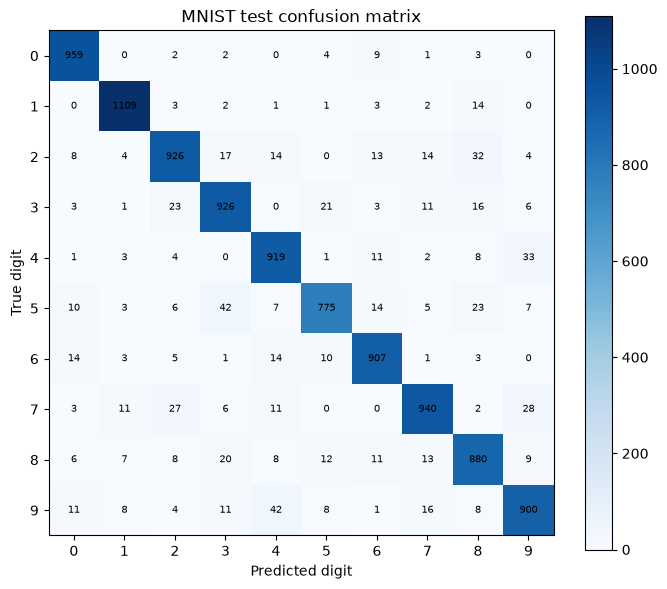

In [9]:
labels = np.arange(NUM_CLASSES)
cm = confusion_matrix(test_labels, predicted_labels, labels=labels)
off_diagonal = cm.copy()
np.fill_diagonal(off_diagonal, 0)
true_digit, predicted_digit = np.unravel_index(np.argmax(off_diagonal), off_diagonal.shape)
most_common_error_count = int(off_diagonal[true_digit, predicted_digit])

report = classification_report(
    test_labels,
    predicted_labels,
    labels=labels,
    output_dict=True,
    zero_division=0,
)
report_frame = pd.DataFrame(report).T
print(
    f"Most frequent confusion: true {true_digit} predicted as "
    f"{predicted_digit} ({most_common_error_count} cases)."
)
print(
    f"Macro precision: {report['macro avg']['precision']:.4f}; "
    f"macro recall: {report['macro avg']['recall']:.4f}."
)
display(report_frame.round(4))

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(cm, cmap="Blues")
fig.colorbar(image, ax=ax)
ax.set_title("MNIST test confusion matrix")
ax.set_xlabel("Predicted digit")
ax.set_ylabel("True digit")
ax.set_xticks(labels)
ax.set_yticks(labels)
for row in range(NUM_CLASSES):
    for column in range(NUM_CLASSES):
        ax.text(column, row, cm[row, column], ha="center", va="center", fontsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dnn_confusion_matrix.png", dpi=150)
display(fig)
plt.close(fig)


**Answer — confusion matrix.** The printed `true → predicted` pair is the class
pair the model confuses most often. The report gives precision (how many
predictions of a digit are correct) and recall (how many true examples of that
digit are found). The macro averages weight all ten digits equally.


## 6. Model tuning

Keras accepts an optimizer object so its learning rate can be set explicitly.
Compare learning rates, optimizers, and one deeper architecture. Each candidate
uses the same validation split, batch size, and five-epoch budget for a fair
short experiment.


In [10]:
tuning_configs = [
    {
        "name": "SGD lr=0.001",
        "optimizer": "sgd",
        "learning_rate": 0.001,
        "hidden_units": (512,),
    },
    {
        "name": "SGD lr=0.05",
        "optimizer": "sgd",
        "learning_rate": 0.05,
        "hidden_units": (512,),
    },
    {
        "name": "RMSprop",
        "optimizer": "rmsprop",
        "learning_rate": 0.001,
        "hidden_units": (512,),
    },
    {
        "name": "Adam",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "hidden_units": (512,),
    },
    {
        "name": "Adam deeper",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "hidden_units": (256, 128),
    },
]

def make_tuned_model(optimizer_name, learning_rate, hidden_units):
    layers = [keras.Input(shape=(28 * 28,), name="pixels")]
    for units in hidden_units:
        layers.append(keras.layers.Dense(units, activation="relu"))
    layers.append(keras.layers.Dense(NUM_CLASSES, activation="softmax"))
    model = keras.Sequential(layers)
    optimizer_class = {
        "sgd": keras.optimizers.SGD,
        "rmsprop": keras.optimizers.RMSprop,
        "adam": keras.optimizers.Adam,
    }[optimizer_name]
    model.compile(
        optimizer=optimizer_class(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

tuning_rows = []
for config in tuning_configs:
    keras.utils.set_random_seed(RANDOM_STATE)
    model = make_tuned_model(
        config["optimizer"],
        config["learning_rate"],
        config["hidden_units"],
    )
    tuned_history = model.fit(
        train_images,
        train_targets,
        epochs=5,
        batch_size=128,
        validation_split=0.10,
        verbose=0,
    )
    tuned_test_loss, tuned_test_accuracy = model.evaluate(
        test_images, test_targets, verbose=0
    )
    tuning_rows.append(
        {
            "model": config["name"],
            "optimizer": config["optimizer"],
            "learning_rate": config["learning_rate"],
            "hidden_units": str(config["hidden_units"]),
            "best_val_accuracy": max(tuned_history.history["val_accuracy"]),
            "test_loss": tuned_test_loss,
            "test_accuracy": tuned_test_accuracy,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("test_accuracy", ascending=False)
    .reset_index(drop=True)
)
tuning_results.to_csv(OUTPUT_DIR / "dnn_tuning_results.csv", index=False)
display(tuning_results.round(4))
best_tuned = tuning_results.iloc[0]
print(
    f"Best short-run test accuracy: {best_tuned['model']} "
    f"({best_tuned['test_accuracy']:.4f})."
)


,model,optimizer,learning_rate,hidden_units,best_val_accuracy,test_loss,test_accuracy
0,RMSprop,rmsprop,0.001,"(512,)",0.9790,0.0733,0.9777
1,Adam,adam,0.001,"(512,)",0.9765,0.0790,0.9745
2,Adam deeper,adam,0.001,"(256, 128)",0.9750,0.0847,0.9736
3,SGD lr=0.05,sgd,0.050,"(512,)",0.9570,0.1938,0.9447
4,SGD lr=0.001,sgd,0.001,"(512,)",0.8377,0.9749,0.8191


Best short-run test accuracy: RMSprop (0.9777).


## 7. Discussion and result

The tuning table is the evidence for the discussion. A larger learning rate
may converge faster but can become unstable; adaptive optimizers can reach a
strong result in fewer epochs; and extra hidden layers increase capacity but
can also increase variance. The best setting depends on the metric and training
budget, not just the model's size.
